# ResoKit's Tutorial

This tutorial is a guide to use ResoKit package.
ResoKit is toolkit package for the analysis and diagnostics of resonances in exoplanetary planetary systems.

In this tutorial we show, step by step, how to get started with the ResoKit package.

---

## Import ResoKit and the necessary packages

In [1]:
import resokit

## Loading the data

The first step is to load an exoplanetary system. The available datasets are [NASA](https://exoplanetarchive.ipac.caltech.edu/) or [EU](https://exoplanet.eu/home/).
Both datasets are provided with the package, and they can be updated if necessary.

To load a system, functions `load_system_from_nasa` and `load_system_from_eu` are provided in the `io` module.

For this turorial, we will work with the  `Kepler-47` exoplanetary system, from the Exoplanet.eu dataset.

In [2]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47")

Looking for star system Kepler-47 in eu database.
 Loading only index columns...
  Reading exoplanet_eu.csv directly from datasets.zip...
 Updated stored index in memory.
 Found an almost exact match: star Kepler-47 A in eu dataset.
 Execute with exact_match=False to load it, or rewrite the name.


If the system (or star in this case) name is entered incorrectly, ResoKit will attempt to detect the intended system and provide suggestions based on it.
As Exoplanet.eu is indexed through star name, we see here that the correct system (star) name is `Kepler-47 A`.

In [3]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47 A", check_binary=True)

Looking for star system Kepler-47 A in eu database.
 Loading rows [4691, 4692, 4693]...
  Reading exoplanet_eu.csv directly from datasets.zip...
Checking if Kepler-47 A is a binary system...
 Found a very close binary match in ['Kepler47']
 Execute with exact_match=False to load it.
Star Kepler-47 A is not part of a binary system.
Creating system Kepler-47 A.
 Star Kepler-47 A created.
 3 planets created.


So, we wil try then to load the system using `exact_match=False`. 

In this case we remove the " A", and keep the hyphen "-".

In [4]:
kepler47 = resokit.io.load_system_from_eu("Kepler-47", exact_match=False, check_binary=True)

Looking for star system Kepler-47 in eu database.
 Found an almost exact match: star Kepler-47 A in eu dataset.
 Loading the almost exact match...
 Loading rows [4691, 4692, 4693]...
  Reading exoplanet_eu.csv directly from datasets.zip...
Checking if Kepler-47 A is a binary system...
 Binary system found in ['Kepler47']
Creating system Kepler-47 A.
 Using binary star Kepler-47 A.
 3 planets created.


Now, `kepler47` is a Static System; and we also know that it is a circumbinary planets system.

We can see its components (star and planets) and where the system was obtained from.

In [5]:
kepler47

StaticSystem: 'Kepler-47 A'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler47 B 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]
from 'eu' data source.

## Analysing the Static System

Some features we can apply to this System are:

- System planets parameters: `get_item`
- Individual planet inspection: `planet`
- Calculate period ratios: `period_ratios`
- Plot planet, star, of general system attributes: `plot`
- Remove or add a planet: `remove`, `add`
We will now explain how to use each of them.

### Inspection

We can access the parameters of every planet as if it were a dataframe, though the slice method

For example the **mass**

In [6]:
kepler47["mass"]

Kepler-47 (AB)b        NaN
Kepler-47 (AB)d    0.05984
Kepler-47 (AB)c        NaN
Name: mass, dtype: float64

Or the **radius** and the **P**eriod

In [7]:
kepler47[["radius", "P"]]

,radius,P
Kepler-47 (AB)b,0.2700,49.514
Kepler-47 (AB)d,0.6281,187.350
Kepler-47 (AB)c,0.4100,303.148


Another method is using the `get_item` method.

For example, for the **e**ccentricity and **inc**lination; and its errors too!

In [8]:
kepler47.get_item(["e", "inc"], error=True)

,e,e_err_min,e_err_max,inc,inc_err_min,inc_err_max
Kepler-47 (AB)b,NaN,NaN,NaN,89.590,0.5,0.5
Kepler-47 (AB)d,0.024,0.017,0.017,90.000,NaN,NaN
Kepler-47 (AB)c,NaN,NaN,NaN,89.826,NaN,NaN


### Planet access

We can access any planet (or even the system star) from the Static System.

For example, if we want to retrieve the 2nd planet (sorted by period), we simply do

In [9]:
planet2 = kepler47.planet(1) # Remember python is 0 indexed, so the second planet is "1".
planet2

,Kepler-47 (AB)d
n_err_min,41.887902
name,Kepler-47 (AB)d
P,187.35
inc_err_min,NaN
inc,90.0
tperi_err_max,NaN
tperi_err_min,NaN
radius,0.6281
P_err_max,0.15
rowupdate,2024-08-12


We can display the planet properties as a Series.

In [10]:
planet2.data

n_err_min                                 41.887902
name                                Kepler-47 (AB)d
P                                            187.35
inc_err_min                                     NaN
inc                                            90.0
tperi_err_max                                   NaN
tperi_err_min                                   NaN
radius                                       0.6281
P_err_max                                      0.15
rowupdate                                2024-08-12
a                                            0.6992
e_err_max                                     0.017
n_err_max                                 41.887902
radius_err_max                               0.0437
P_err_min                                      0.15
disc_year                                    2013.0
mass_sin_i                                      NaN
mass_sin_i_err_min                              NaN
radius_err_min                               0.0437
a_err_min   

And we can acces any of this attributes.
For example the _name_, or the semi-major axis _a_:

In [11]:
planet2.name

'Kepler-47 (AB)d'

In [12]:
planet2.a

0.6992

Just, remember the main units!
Semimajor-axis ($a$) is in Astronomical Units.

### Calculate and plot (if possible) period ratios

If we want to obtain the period ratio between all pair of planets: $P_{i+1}/P_{i}$, we simply invoke Static System `period_ratios_` attribute.

In [13]:
kepler47.period_ratios_

,Kepler47 B,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler47 B,1.000000,5.729139,21.677794,35.076487
Kepler-47 (AB)b,0.174546,1.000000,3.783778,6.122470
Kepler-47 (AB)d,0.046130,0.264286,1.000000,1.618084
Kepler-47 (AB)c,0.028509,0.163333,0.618015,1.000000


Here we can see that $P_\textnormal{Kepler-47 (AB)c} \sim 6.122470 \times P_\textnormal{Kepler-47 (AB)b}$ .

If we want to get the period ratios as fractions, we simply invoke Static System `pair_ratio` method, including (if wanted) any `resokit.utils.float_to_fraction` fuction argument. For example: _max_error_ (which is the maximum relative error between the estimated fraction and the floating period ratio).

In [14]:
kepler47.pair_ratio("all", max_error=1e-1, use_binary=False)

Approximating float 1.000000 as a continued fraction:
 Iter  1:   1/1   -> 1.000000 (error: 0.00e+00)
Approximating float 0.264286 as a continued fraction:
 Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
 Iter  2:   1/3   -> 0.333333 (error: 2.61e-01)
 Iter  3:   1/4   -> 0.250000 (error: 5.41e-02)
Approximating float 0.163333 as a continued fraction:
 Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
 Iter  2:   1/6   -> 0.166667 (error: 2.04e-02)
Approximating float 3.783778 as a continued fraction:
 Iter  1:   3/1   -> 3.000000 (error: 2.07e-01)
 Iter  2:   4/1   -> 4.000000 (error: 5.71e-02)
Approximating float 1.000000 as a continued fraction:
 Iter  1:   1/1   -> 1.000000 (error: 0.00e+00)
Approximating float 0.618015 as a continued fraction:
 Iter  1:   0/1   -> 0.000000 (error: 1.00e+00)
 Iter  2:   1/1   -> 1.000000 (error: 6.18e-01)
 Iter  3:   1/2   -> 0.500000 (error: 1.91e-01)
 Iter  4:   2/3   -> 0.666667 (error: 7.87e-02)
Approximating float 6.122470 as a continued fraction

,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler-47 (AB)b,"(1, 1)","(4, 1)","(6, 1)"
Kepler-47 (AB)d,"(1, 4)","(1, 1)","(3, 2)"
Kepler-47 (AB)c,"(1, 6)","(2, 3)","(1, 1)"


Here, is more clear that $P_\textnormal{Kepler-47 (AB)b}$ and $P_\textnormal{Kepler-47 (AB)c}$ are somewhat _close_ to a $6/1$ mean motion resonance.
Moreover, we also see that $P_\textnormal{Kepler-47 (AB)d}$ and $P_\textnormal{Kepler-47 (AB)c}$ are somewhat _close_ to a $3/2$ mean motion resonance.

In case the errors (of the period ratio estimations) are needed, they can be obtained invoking Static System  `pair_ratio` method again, with `errors=True`.
They are calculated using each observed period error, so each value is an upper limit for the error.

In [15]:
kepler47.pair_ratio(error=True, use_binary=True)

,Kepler47 B,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler47 B,NaN,NaN,NaN,NaN
Kepler-47 (AB)b,None,0.001142,0.004304,0.005155
Kepler-47 (AB)d,None,0.000301,0.001132,0.001351
Kepler-47 (AB)c,None,0.000138,0.000516,0.000336


In [16]:
kepler47.pair_ratio("all", error=True)

,Kepler47 B,Kepler-47 (AB)b,Kepler-47 (AB)d,Kepler-47 (AB)c
Kepler47 B,NaN,NaN,NaN,NaN
Kepler-47 (AB)b,None,0.001142,0.004304,0.005155
Kepler-47 (AB)d,None,0.000301,0.001132,0.001351
Kepler-47 (AB)c,None,0.000138,0.000516,0.000336


#### Plot

If the system has a _triplet_ (three planets or more), it can be plotted in a period ratios separations space: $P_{i+1}/P_{i}$ vs. $P_{i+2}/P_{i+1}$.
To do so, we invoke Static System `plot_triplet` method. Here, we also plot the errors.

Text(0, 0.5, 'Period Ratio ($P_3/P_2$)')

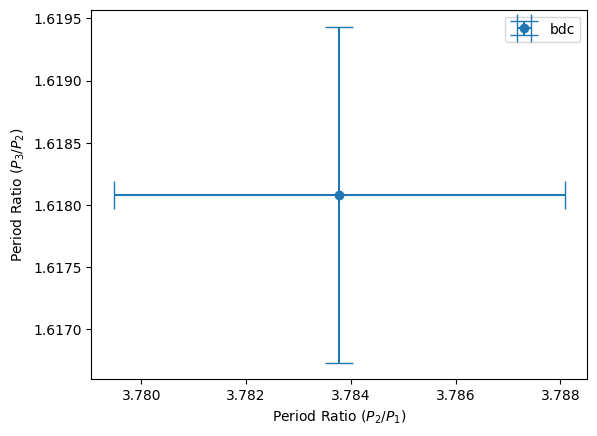

In [17]:
ax = kepler47.plot_triplet(error=True, capsize=10)
ax.legend()
ax.set_xlabel("Period Ratio ($P_2/P_1$)")
ax.set_ylabel("Period Ratio ($P_3/P_2$)")

If we want to plot some 3-body mean motion resonaces near the system triplets, we can invoke the `resokit.utils.mmr.plot_mmrs`_` method. 

This method will plot the resonances that are near the triplets.

Note: It its higly recommended to set the axes limits (xlim and ylim) **before** calling `plot_mmrs`, especially if *label_mmrs=True*.

Text(0, 0.5, 'Period Ratio ($P_3/P_2$)')

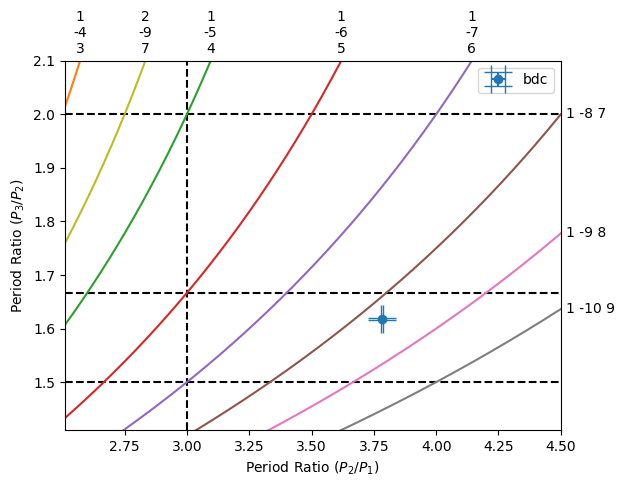

In [18]:
bounds = [2.51, 4.5, 1.41, 2.1]  # [xmin, xmax, ymin, ymax]
ax = kepler47.plot_triplet(error=True, capsize=10, label=True)
ax.set_xlim(bounds[0], bounds[1])
ax.set_ylim(bounds[2], bounds[3])
resokit.utils.mmr.plot_mmrs(
    bounds=bounds,
    ax=ax,
    label_mmrs=True
    )
ax.legend()
ax.set_xlabel("Period Ratio ($P_2/P_1$)")
ax.set_ylabel("Period Ratio ($P_3/P_2$)")

Here, the 3-body resonances are annotated with the corresponding period ratios.

### Plot

We can plot any pair atributes of the StaticSystem, of any planet in the system.

Text(0, 0.5, 'Radius ($R_J$)')

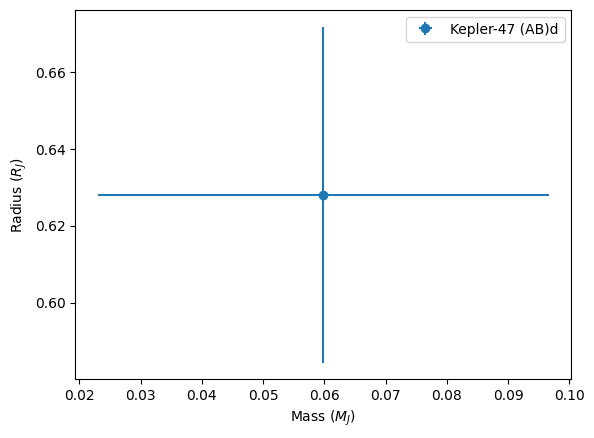

In [19]:
ax = kepler47.plot("mass", "radius", error_x=True, error_y=True)
ax.legend()
ax.set_xlabel("Mass ($M_J$)")
ax.set_ylabel("Radius ($R_J$)")

Some planets are not plotted because they do not have both requested attributes measured.

For example, in this case...

In [20]:
kepler47["radius"]

Kepler-47 (AB)b    0.2700
Kepler-47 (AB)d    0.6281
Kepler-47 (AB)c    0.4100
Name: radius, dtype: float64

We see the three planets have radius estimations; but...

In [21]:
kepler47["mass"]

Kepler-47 (AB)b        NaN
Kepler-47 (AB)d    0.05984
Kepler-47 (AB)c        NaN
Name: mass, dtype: float64

only `Kepler-47 (AB)d` has its mass estimated.

**EXTRA**

`ResoKit` also provides tools for mass (or radius) estimation with diverse models, from the estimated radius (or mass).

To do so, we simply use `estimate_mass` function.

In [22]:
kepler47.estimate_mass()

Kepler-47 (AB)b    0.028560
Kepler-47 (AB)d    0.059840
Kepler-47 (AB)c    0.058047
Name: mass, dtype: float64

Here we used the default `estimate_mass` parameters, but we can get different estimations with different models, and also include the errors.

In [23]:
kepler47.estimate_mass(model="m24", err_method=2)

,mass,mass_err_min,mass_err_max
Kepler-47 (AB)b,0.037818,0.002276,0.002322
Kepler-47 (AB)d,0.059840,0.036800,0.036800
Kepler-47 (AB)c,0.070546,0.004572,0.004672


## Remove or add planets

### Remove

To remove a planet, we can simply invoke the `remove_planet` method of StaticSystem.

In [24]:
modified_kepler47 = kepler47.remove_planet(2)  # Remember python is 0 indexed, so the third planet is "2".
modified_kepler47

Planet Kepler-47 (AB)c [2] removed.


StaticSystem: 'Kepler-47 A'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler47 B 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
 [circumbinary system]
from 'eu' data source.

We can also remove planets by suffix.

In [25]:
modified_kepler47.suffixes_

['A', 'B', 'b', 'd']

In [26]:
modified_kepler47 = kepler47.remove_planet("b")
modified_kepler47

Planet Kepler-47 (AB)b [0] removed.


StaticSystem: 'Kepler-47 A'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler47 B 
 Planets:
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]
from 'eu' data source.

In [27]:
# We check that the number of planets has been reduced
modified_kepler47.n_planets_

2

We can look the new system metadata, and we will find that 'removed_planet' has been added. Also some extra information can be found...

In [28]:
for k,v in modified_kepler47.metadata.items():
    print(k, v)

ResoKit 0.0.1
author Emmanuel Gianuzzi
author_email egianuzzi@unc.edu.ar
affiliation FAMAF-IATE-OAC-CONICET
platform Linux-6.8.0-52-generic-x86_64-with-glibc2.35
system_encoding utf-8
python 3.10.12 (main, Jan 17 2025, 14:35:34) [GCC 11.4.0]
license MIT
load_system Kepler-47
eu_indexes [4691, 4692, 4693]
removed_planet ['Kepler-47 (AB)b']


### Add

To add a planet, we can simply invoke the `add_planet` method of StaticSystem.

In [29]:
# Get a planet from the original system
planet2 = kepler47.planet(1)  # Remember python is 0 indexed, so the second planet is "1".

In [30]:
# Add the planet to the modified system
modified_kepler47.add_planet(planet2)

Planet Kepler-47 (AB)d added.


<attrs generated init resokit.core.StaticSystem>:31: UserWarning: Planets must have unique names.
  self.__attrs_post_init__()


StaticSystem: 'Kepler-47 A'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler47 B 
 Planets:
  Kepler-47 (AB)d
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]
from 'eu' data source.

Here, we added a planet that already exists in the system, so a Warning was raised.

In [31]:
# Extract the planet 2 from the original system
planet2 = kepler47.planet(1)  # Remember python is 0 indexed, so the second planet is "1".

# Remove the planet from the original system
modified_kepler47 = kepler47.remove_planet(1)

# Add the planet to the modified system
modified_kepler47 = modified_kepler47.add_planet(planet2)

# Check that the planet has been added
modified_kepler47

Planet Kepler-47 (AB)d [1] removed.
Planet Kepler-47 (AB)d added.


StaticSystem: 'Kepler-47 A'
 Star 1:
  Kepler-47 A
 Star 2:
  Kepler47 B 
 Planets:
  Kepler-47 (AB)b
  Kepler-47 (AB)d
  Kepler-47 (AB)c
 [circumbinary system]
from 'eu' data source.